# J&F Realty Insighters Final Project Notebook  
### ADS508 Data Science with Cloud Computing

**Authors:** Jun Sik Ryu and Faye Shawntel Corprew

## Project Overview

J&F Realty Insighters is a real estate analytics company focused on identifying the factors that influence housing price trends across metropolitan areas.  
The goal of this project is to predict the Zillow Home Value Index, or ZHVI, using housing supply, demand, and prior trend indicators sourced from Zillow datasets and processed in an AWS based workflow.

### Business Problem
Traditional real estate analysis often relies on manual trend review and expert intuition. Because housing prices are influenced by multiple interacting factors, a machine learning pipeline can provide more scalable and consistent decision support for identifying promising markets.

### Notebook Roadmap
This notebook is organized as a single end to end workflow:

1. Load and inspect the prepared dataset  
2. Review data quality and exploratory findings  
3. Select features for modeling  
4. Train a baseline model and a Random Forest model  
5. Evaluate predictive performance  
6. Interpret feature importance  
7. Summarize findings, limitations, and future enhancements

## AWS and Data Pipeline Context

The broader project pipeline used the following cloud workflow:

- Raw Zillow data stored in Amazon S3  
- Exploration and notebook development in Amazon SageMaker Studio  
- Transformation from wide format to long format during data preparation  
- Feature engineering using lagged and percentage change variables  
- Model training using Python and scikit learn in SageMaker  

For the final consolidated notebook below, the prepared modeling dataset is loaded directly from a local file when available, with an AWS S3 path included as a fallback reference.

In [70]:
import warnings
warnings.filterwarnings("ignore")
import math
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Final Prepared Dataset

The project's final prepared dataset combines the following Zillow based data sources:

- Zillow Home Value Index  
- Housing Inventory  
- Market Temperature Index  
- Median Sale Price  

The transformed dataset already includes time based variables and engineered lag features created in the earlier module notebooks.

In [71]:
#Path = Data File Location

LOCAL_DATA_PATH = r"C:\Users\imss\Desktop\USD\2026\ADS508\Final\ADS508_Final\Prepared\full_prepared_dataset.csv"
S3_DATA_PATH = "s3://ads508-housing-data-faye/prepared/full_prepared_dataset.csv"

if Path(LOCAL_DATA_PATH).exists():
    data_path = LOCAL_DATA_PATH
else:
    data_path = S3_DATA_PATH

df = pd.read_csv(data_path)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(f"Loaded data from: {data_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded data from: C:\Users\imss\Desktop\USD\2026\ADS508\Final\ADS508_Final\Prepared\full_prepared_dataset.csv
Shape: (82786, 17)


,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI,Inventory,MarketTemp,MedianSalePrice,Year,Month,ZHVI_Lag1,Inventory_Lag1,MarketTemp_Lag1,ZHVI_PctChange,Inventory_PctChange
0,394297,677,"Aberdeen, SD",msa,SD,2018-04-30,151243.332163,205.0,44.0,NaN,2018,4,150947.408155,189.0,41.0,0.001960,0.084656
1,394297,677,"Aberdeen, SD",msa,SD,2018-05-31,151561.875115,231.0,50.0,NaN,2018,5,151243.332163,205.0,44.0,0.002106,0.126829
2,394297,677,"Aberdeen, SD",msa,SD,2018-06-30,151737.806399,263.0,52.0,NaN,2018,6,151561.875115,231.0,50.0,0.001161,0.138528
3,394297,677,"Aberdeen, SD",msa,SD,2018-07-31,152341.825731,294.0,51.0,NaN,2018,7,151737.806399,263.0,52.0,0.003981,0.117871
4,394297,677,"Aberdeen, SD",msa,SD,2018-08-31,152652.372110,309.0,48.0,NaN,2018,8,152341.825731,294.0,51.0,0.002038,0.051020


## Data Dictionary Snapshot

The key variables used in the final modeling dataset are:

- **ZHVI:** Zillow Home Value Index and final target variable  
- **Inventory:** Number of homes listed for sale  
- **MarketTemp:** Zillow market competitiveness indicator  
- **MedianSalePrice:** Observed sale price measure used as a contextual market feature  
- **Year, Month:** Time based features  
- **ZHVI_Lag1, Inventory_Lag1, MarketTemp_Lag1:** Prior period values used to capture temporal dependence  
- **ZHVI_PctChange, Inventory_PctChange:** Momentum style features reflecting recent relative change

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82786 entries, 0 to 82785
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   RegionID             82786 non-null  int64         
 1   SizeRank             82786 non-null  int64         
 2   RegionName           82786 non-null  object        
 3   RegionType           82786 non-null  object        
 4   StateName            82786 non-null  object        
 5   Date                 82786 non-null  datetime64[ns]
 6   ZHVI                 82786 non-null  float64       
 7   Inventory            82750 non-null  float64       
 8   MarketTemp           82202 non-null  float64       
 9   MedianSalePrice      14308 non-null  float64       
 10  Year                 82786 non-null  int64         
 11  Month                82786 non-null  int64         
 12  ZHVI_Lag1            82786 non-null  float64       
 13  Inventory_Lag1       82786 non-

In [73]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
RegionID,82786.0,NaN,NaN,NaN,412458.03282,394297.0,394548.0,394798.0,395046.0,753929.0,77710.414749
SizeRank,82786.0,NaN,NaN,NaN,457.972652,1.0,228.0,455.0,684.0,939.0,267.041342
RegionName,82786,894,"Zanesville, OH",94,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RegionType,82786,1,msa,82786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StateName,82786,50,TX,6152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,82786,NaN,NaN,NaN,2022-03-23 09:46:03.858623232,2018-04-30 00:00:00,2020-03-31 00:00:00,2022-03-31 00:00:00,2024-02-29 00:00:00,2026-01-31 00:00:00,NaN
ZHVI,82786.0,NaN,NaN,NaN,241769.74908,46486.936299,148692.101704,198673.747285,283446.903424,1596557.24204,153473.163156
Inventory,82750.0,NaN,NaN,NaN,1238.785982,10.0,154.0,317.0,786.0,97260.0,3923.54888
MarketTemp,82202.0,NaN,NaN,NaN,54.168877,-84.0,41.0,52.0,66.0,240.0,22.451946
MedianSalePrice,14308.0,NaN,NaN,NaN,317865.741424,84562.25,203722.9375,268410.0,377461.95,1661250.0,174918.675412


## Data Quality Review

Confirm that the final prepared file is structurally sound before modeling.

In [74]:
missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .rename("MissingCount")
      .to_frame()
)
missing_summary["MissingPercent"] = (missing_summary["MissingCount"] / len(df)) * 100
missing_summary.head(20)

,MissingCount,MissingPercent
MedianSalePrice,68478,82.716884
MarketTemp,584,0.705433
Inventory_PctChange,36,0.043486
Inventory,36,0.043486
RegionID,0,0.000000
StateName,0,0.000000
RegionType,0,0.000000
SizeRank,0,0.000000
RegionName,0,0.000000
Date,0,0.000000


The missingness pattern shows that `MedianSalePrice` has substantial gaps, while most engineered features are complete after the preparation workflow.  
This matches the earlier project observation that some Zillow series had incomplete coverage across metros and dates.

In [75]:
df = df.dropna(subset=["ZHVI"]).copy()
df = df.sort_values(["RegionName", "Date"]).copy()
df = df.dropna(subset=["Inventory", "MarketTemp"]).copy()
df = df.dropna(subset=["MedianSalePrice"]).copy()

print(df.isnull().sum())
print(df.shape)

RegionID               0
SizeRank               0
RegionName             0
RegionType             0
StateName              0
Date                   0
ZHVI                   0
Inventory              0
MarketTemp             0
MedianSalePrice        0
Year                   0
Month                  0
ZHVI_Lag1              0
Inventory_Lag1         0
MarketTemp_Lag1        0
ZHVI_PctChange         0
Inventory_PctChange    0
dtype: int64
(14305, 17)


In [76]:
print("Unique regions:", df["RegionName"].nunique())
print("Unique states:", df["StateName"].nunique())
print("Date range:", df["Date"].min(), "to", df["Date"].max())

Unique regions: 161
Unique states: 42
Date range: 2018-04-30 00:00:00 to 2026-01-31 00:00:00


## Exploratory Data Analysis

The final notebook follows the example project style by including a small number of focused visuals that help explain the business problem rather than overwhelming the reader with many disconnected plots.

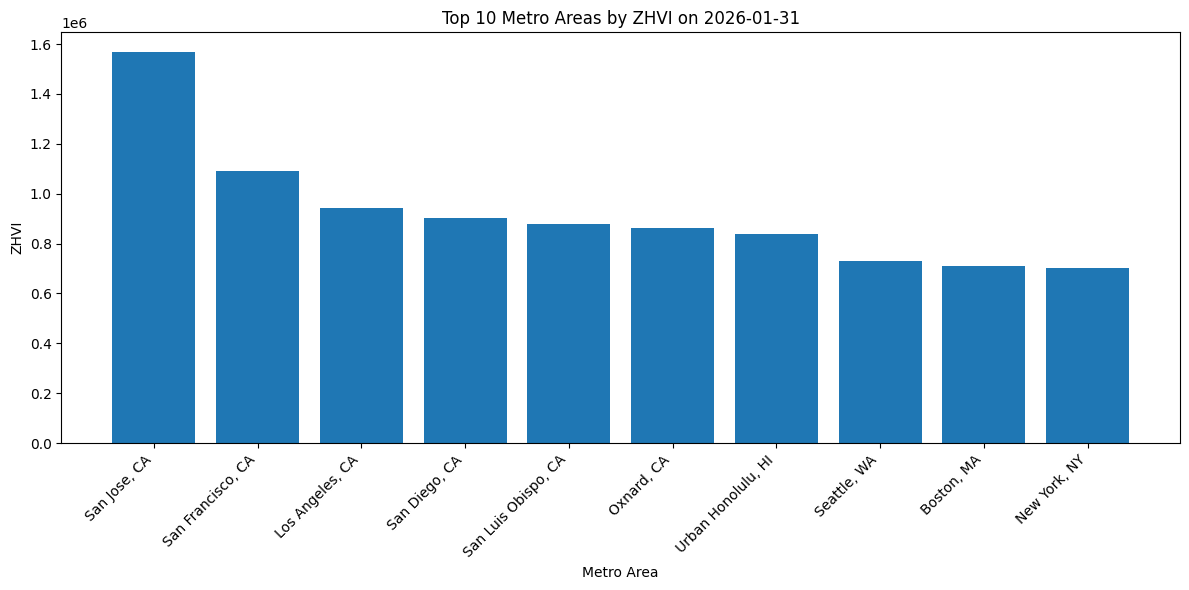

In [77]:
latest_date = df["Date"].max()
top_10_latest = (
    df.loc[df["Date"] == latest_date, ["RegionName", "ZHVI"]]
      .dropna()
      .sort_values("ZHVI", ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
plt.bar(top_10_latest["RegionName"], top_10_latest["ZHVI"])
plt.xticks(rotation=45, ha="right")
plt.title(f"Top 10 Metro Areas by ZHVI on {latest_date.date()}")
plt.xlabel("Metro Area")
plt.ylabel("ZHVI")
plt.tight_layout()
plt.show()

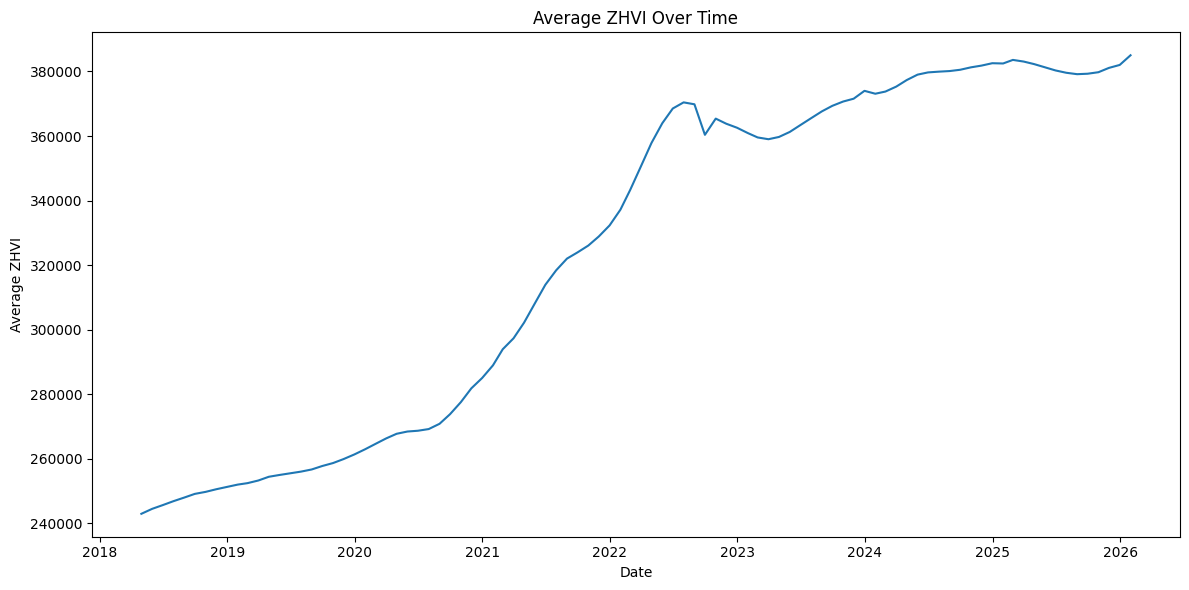

In [78]:
monthly_trend = (
    df.groupby("Date")[["ZHVI", "Inventory", "MarketTemp"]]
      .mean()
      .reset_index()
      .sort_values("Date")
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend["Date"], monthly_trend["ZHVI"])
plt.title("Average ZHVI Over Time")
plt.xlabel("Date")
plt.ylabel("Average ZHVI")
plt.tight_layout()
plt.show()

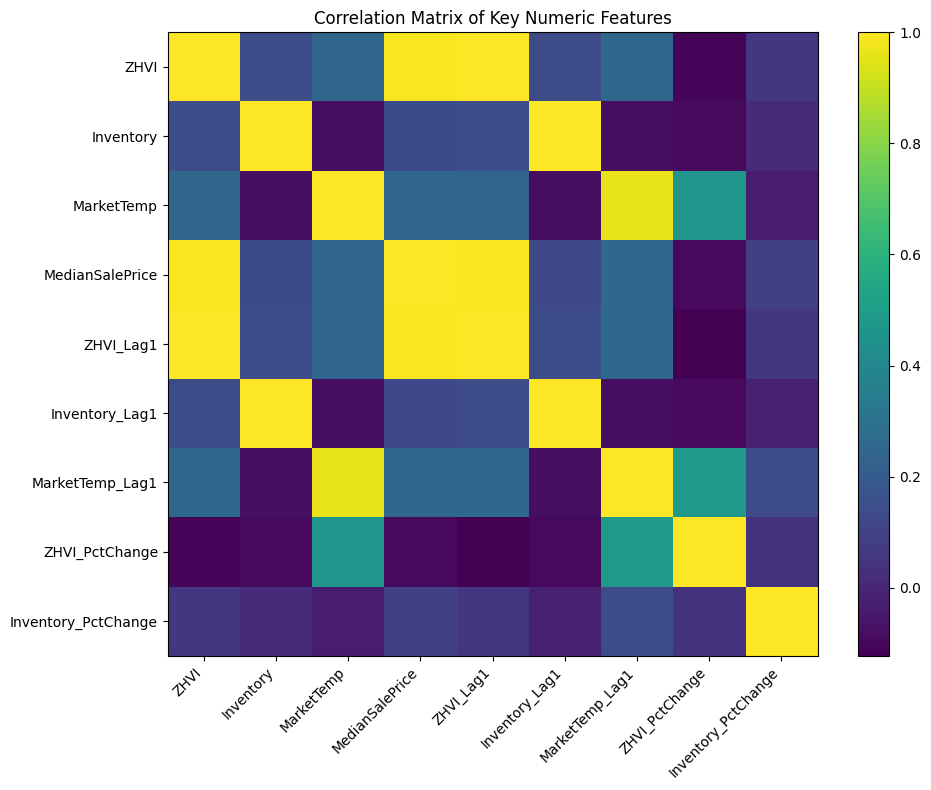

,ZHVI,Inventory,MarketTemp,MedianSalePrice,ZHVI_Lag1,Inventory_Lag1,MarketTemp_Lag1,ZHVI_PctChange,Inventory_PctChange
ZHVI,1.000000,0.141454,0.248243,0.990666,0.999857,0.139975,0.259045,-0.107762,0.059441
Inventory,0.141454,1.000000,-0.081449,0.128920,0.142335,0.997976,-0.077996,-0.092144,0.016451
MarketTemp,0.248243,-0.081449,1.000000,0.237457,0.241415,-0.079046,0.963325,0.462148,-0.038760
MedianSalePrice,0.990666,0.128920,0.237457,1.000000,0.990247,0.126075,0.256931,-0.095660,0.091642
ZHVI_Lag1,0.999857,0.142335,0.241415,0.990247,1.000000,0.140869,0.251713,-0.122371,0.058306
Inventory_Lag1,0.139975,0.997976,-0.079046,0.126075,0.140869,1.000000,-0.081657,-0.091838,-0.020010
MarketTemp_Lag1,0.259045,-0.077996,0.963325,0.256931,0.251713,-0.081657,1.000000,0.486872,0.133367
ZHVI_PctChange,-0.107762,-0.092144,0.462148,-0.095660,-0.122371,-0.091838,0.486872,1.000000,0.043650
Inventory_PctChange,0.059441,0.016451,-0.038760,0.091642,0.058306,-0.020010,0.133367,0.043650,1.000000


In [79]:
corr_cols = [
    "ZHVI", "Inventory", "MarketTemp", "MedianSalePrice",
    "ZHVI_Lag1", "Inventory_Lag1", "MarketTemp_Lag1",
    "ZHVI_PctChange", "Inventory_PctChange"
]

corr_matrix = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Matrix of Key Numeric Features")
plt.colorbar()
plt.tight_layout()
plt.show()

corr_matrix

### Exploratory Findings

The exploratory review supports three main observations:

1. Housing values vary substantially across metro areas, indicating strong regional heterogeneity.  
2. Time based behavior is visible in the aggregated ZHVI trend, which supports inclusion of lag and temporal features.  
3. Sale price and lagged home value features appear strongly associated with current ZHVI, suggesting that recent market history carries substantial predictive signal.

## Feature Selection and Modeling Setup

The final notebook is aligned to the design document by using **ZHVI** as the prediction target.

### Modeling Choice
A Random Forest Regressor was selected because it can:

- capture nonlinear relationships in tabular housing data  
- handle mixed feature types through a preprocessing pipeline  
- provide feature importance estimates  
- perform well without explicit feature scaling

A simple baseline model is also included so the final model can be compared against a naive benchmark.

In [80]:
feature_cols = [
    "StateName",
    "Year",
    "Month",
    "Inventory",
    "MarketTemp",
    "MedianSalePrice",
    "ZHVI_Lag1",
    "Inventory_Lag1",
    "MarketTemp_Lag1",
    "ZHVI_PctChange",
    "Inventory_PctChange"
]

target_col = "ZHVI"

df_model = df.dropna(subset=[target_col]).copy()

X = df_model[feature_cols]
y = df_model[target_col]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (14305, 11)
Target vector shape: (14305,)


In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:", X_test.shape, y_test.shape)

Training shape: (11444, 11) (11444,)
Testing shape: (2861, 11) (2861,)


In [82]:
numeric_features = [c for c in feature_cols if c != "StateName"]
categorical_features = ["StateName"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy="mean"))
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

## Train Baseline and Random Forest Models

In [83]:
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_test)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Training complete.")

Training complete.


In [84]:
def regression_metrics(y_true, y_pred, model_name):
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mean_absolute_error(y_true, y_pred)],
        "RMSE": [math.sqrt(mean_squared_error(y_true, y_pred))],
        "R2": [r2_score(y_true, y_pred)]
    })

results_df = pd.concat([
    regression_metrics(y_test, baseline_preds, "Baseline Mean Model"),
    regression_metrics(y_test, rf_preds, "Random Forest")
], ignore_index=True)

results_df

,Model,MAE,RMSE,R2
0,Baseline Mean Model,124077.838149,170976.859445,-0.001270
1,Random Forest,552.294274,1472.020152,0.999926


The Random Forest model should substantially outperform the baseline because the housing market signal is strongly encoded in the lagged and market context variables.  
A near perfect score should be interpreted carefully, since lagged target derived features and a random train test split can make prediction easier than a true future facing forecast task.

In [85]:
comparison_df = pd.DataFrame({
    "Actual_ZHVI": y_test.values[:10],
    "Baseline_Prediction": baseline_preds[:10],
    "RF_Prediction": rf_preds[:10]
})

comparison_df

,Actual_ZHVI,Baseline_Prediction,RF_Prediction
0,192320.039701,326929.338191,192085.661706
1,199973.096068,326929.338191,200244.094823
2,173588.027578,326929.338191,173551.486556
3,210487.171341,326929.338191,210626.358540
4,166221.923612,326929.338191,166174.019393
5,350575.186377,326929.338191,350426.329589
6,429152.900351,326929.338191,428984.785367
7,292276.567687,326929.338191,292066.393749
8,249028.051313,326929.338191,249553.045314
9,456323.944012,326929.338191,457202.242128


## Visual Evaluation

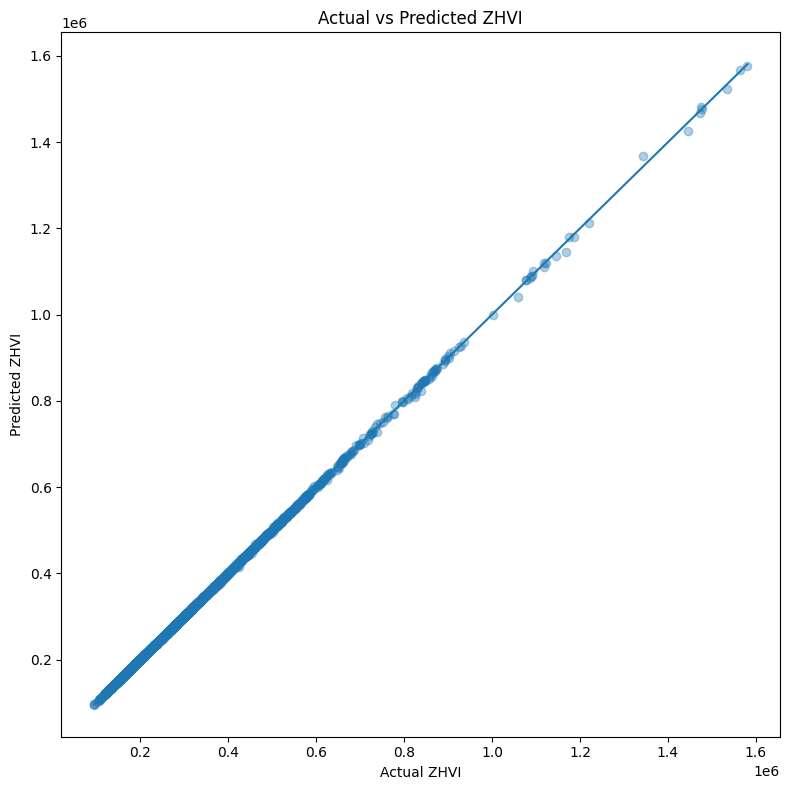

In [86]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_preds, alpha=0.35)
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Actual ZHVI")
plt.ylabel("Predicted ZHVI")
plt.title("Actual vs Predicted ZHVI")
plt.tight_layout()
plt.show()

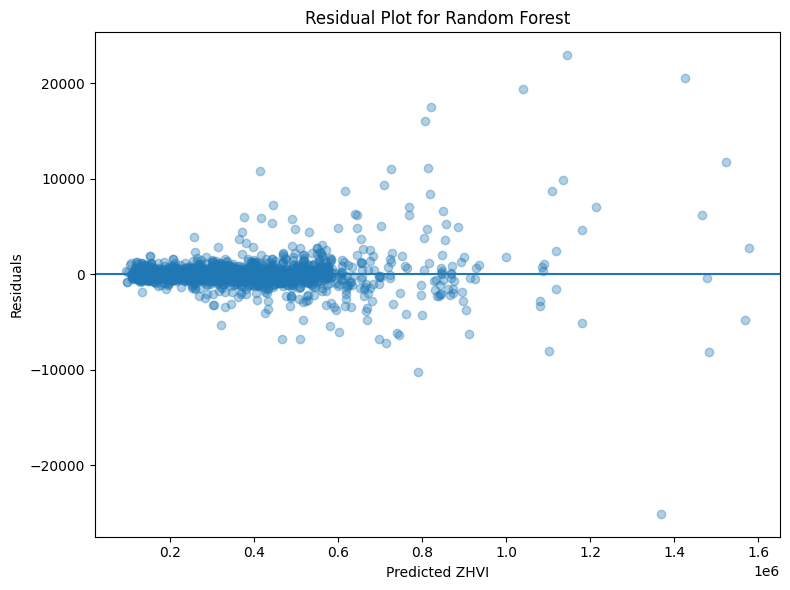

In [87]:
rf_residuals = y_test - rf_preds

plt.figure(figsize=(8, 6))
plt.scatter(rf_preds, rf_residuals, alpha=0.35)
plt.axhline(y=0)
plt.xlabel("Predicted ZHVI")
plt.ylabel("Residuals")
plt.title("Residual Plot for Random Forest")
plt.tight_layout()
plt.show()

## Feature Importance

This section supports interpretability by showing which features contribute most strongly to the Random Forest model.  
That is important from a business perspective because investors and decision makers need more than just a prediction. They need to understand the major drivers behind it.

In [88]:
rf_regressor = rf_model.named_steps["regressor"]
fitted_preprocessor = rf_model.named_steps["preprocessor"]

encoded_cat_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + list(encoded_cat_names)

importance_df = (
    pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": rf_regressor.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(15)

,Feature,Importance
5,ZHVI_Lag1,9.989051e-01
4,MedianSalePrice,8.165218e-04
8,ZHVI_PctChange,1.505483e-04
7,MarketTemp_Lag1,2.836113e-05
2,Inventory,2.806470e-05
3,MarketTemp,1.956305e-05
6,Inventory_Lag1,1.894771e-05
9,Inventory_PctChange,1.138155e-05
0,Year,1.029598e-05
1,Month,8.747637e-06


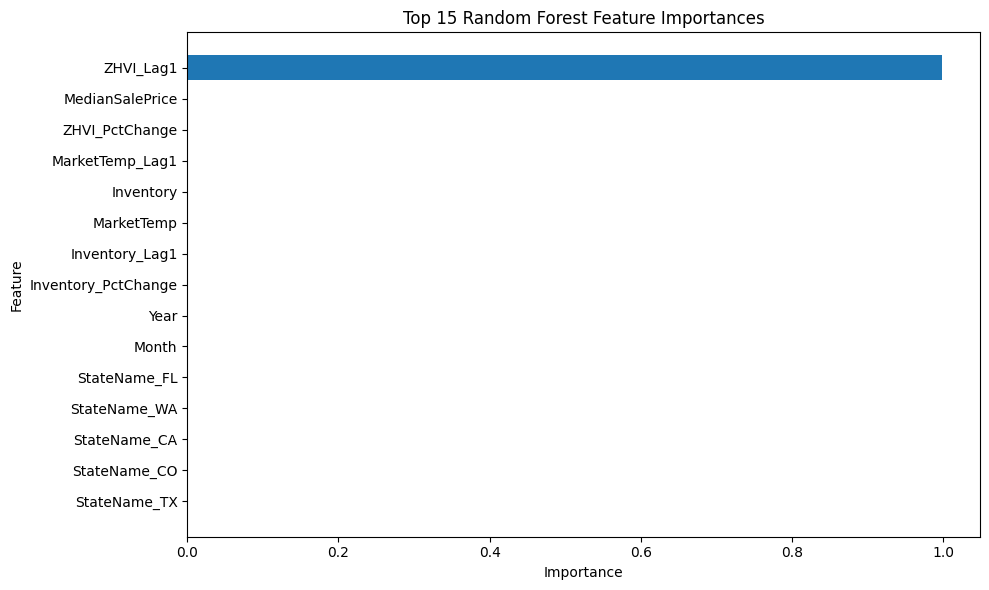

In [89]:
top_features = importance_df.head(15).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Key Findings

Based on the consolidated workflow, the project supports the following conclusions:

- Recent housing value history is one of the strongest predictors of current housing value.  
- Inventory and market temperature provide useful complementary information about supply and demand conditions.  
- The pipeline demonstrates that housing market indicators can be integrated into a scalable cloud based machine learning workflow for regional trend estimation.

## Limitations

This final notebook is strong as a modeling demonstration, but several limitations should be acknowledged:

1. **Random train test split:** Because housing data is time ordered, a random split can introduce temporal leakage.  
2. **Lagged target derived features:** Features such as prior ZHVI and ZHVI percentage change are highly predictive, but they can inflate performance if the evaluation strategy is not time aware.  
3. **External variables not included:** Interest rates, unemployment, school quality, and other macroeconomic factors were not incorporated.  
4. **Prepared dataset focus:** This notebook emphasizes the final integrated dataset rather than rebuilding every raw source transformation step from scratch.

## Future Enhancements

The next improvements for this project are:

1. Replace the random split with a time series validation approach.  
2. Add macroeconomic and demographic features to improve generalizability.  
3. Automate the monthly ETL process using AWS Glue and scheduled SageMaker workflows.  
4. Extend monitoring with model drift checks and retraining triggers.

## Production Deployment Plan

A practical AWS deployment path for this project would be:

1. Store the prepared dataset and model artifacts in Amazon S3.  
2. Package the final preprocessing plus Random Forest pipeline as a serialized model artifact.  
3. Deploy the model through an Amazon SageMaker endpoint for on demand inference or use batch prediction for scheduled market reports.  
4. Monitor data quality and model behavior over time.  
5. Retrain the model periodically as new Zillow data becomes available.

In [90]:
# Optional: save the trained final model artifact locally
joblib.dump(rf_model, "ADS508_GROUP6_final_rf_model.joblib")
print("Saved model artifact as ADS508_GROUP6_final_rf_model.joblib")

Saved model artifact as ADS508_GROUP6_final_rf_model.joblib


## Conclusion

This notebook consolidates the project into a single technical artifact suitable for the final repository.  
It follows the overall structure used in the course examples while remaining aligned with the J&F Realty Insighters business problem, AWS workflow, and final design document.